# Visualização dos dados

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)

## Bibliotecas

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## Funções

In [3]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
        else:
            feature_dfs.append(pd.read_csv(file))
    
    # Renomeando as colunas
    for i, df in enumerate(feature_dfs):
        columns = ["timestamp", f"sensor_{i}"]
        
        df.columns = columns
    
    columns = ["timestamp", "target"]
    target_df.columns = columns
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

## Carregando os dados

In [20]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)
industry_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,156.908398,310.022461,101.547023,71.130001,9.271792,1513.429451,197.014054,33.066858,553.695424,...,426.651658,140.957957,223.192894,69.511954,4.548754,1842.687291,721.402437,120.531554,2121.942413,1463.647280
2018-04-01 00:01:00,0,160.845276,306.084796,71.846296,98.697513,7.989979,1264.045436,549.491578,165.013373,864.166251,...,375.316113,148.975866,1225.833795,92.131989,7.887998,1810.309041,656.074488,94.319273,1914.209147,1437.274642
2018-04-01 00:02:00,0,157.841402,353.863854,59.174616,39.329786,8.771413,1357.757041,710.303108,68.023284,815.342106,...,444.809188,94.262093,42.455318,86.164997,4.975919,1508.671751,1060.796664,40.182165,1805.064984,1565.113515
2018-04-01 00:03:00,0,156.106507,301.563110,0.674927,126.751846,9.234399,1416.592337,451.379204,140.740890,773.406188,...,414.052496,154.828040,525.719895,32.473642,6.304142,1483.740243,719.418238,64.405477,1295.933558,1966.270851
2018-04-01 00:04:00,0,163.462727,298.957820,71.785623,41.526627,9.101509,1468.721792,1014.853751,113.162924,574.974685,...,431.548430,137.733814,950.064772,37.866648,1.671733,1600.106478,995.108386,31.432756,1765.669551,1396.339609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,62.866123,432.326663,77.001917,65.363544,19.892409,1232.957436,1109.264083,118.109623,656.615973,...,NaN,125.823406,573.821696,64.660949,6.066461,1536.191947,1636.798313,26.951498,1830.736428,1374.907651
2018-08-31 23:56:00,0,62.559359,402.294815,32.268873,103.837882,19.871804,1137.196994,834.517562,76.645996,895.475564,...,NaN,181.885424,446.990809,59.595192,4.057784,1573.813766,1333.129871,57.522306,1691.045537,1588.607137
2018-08-31 23:57:00,0,56.077536,269.339456,87.497962,129.919948,19.719878,1022.073096,427.420013,100.267292,700.493429,...,NaN,135.716614,1058.093047,84.392649,6.751912,1552.763450,953.370947,20.965076,1972.697864,1574.224086


## Visualizando dados temporais

## Visualizando distribuição das classes

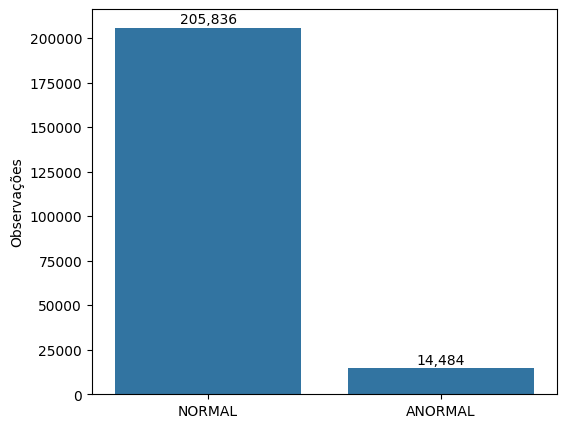

In [14]:
counts = industry_df["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(x=["NORMAL", "ANORMAL"], y=counts, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=1)

plt.ylabel("Observações")
plt.show()

In [15]:
percentuais = industry_df["target"].value_counts(normalize=True).sort_index().mul(100).round(2)

for classe, percentual in percentuais.items():
    nome = "NORMAL" if classe == 0 else "ANORMAL"
    print(f"{nome}: {percentual:.2f}%")

NORMAL: 93.43%
ANORMAL: 6.57%


Com essas informações podemos ver que o dataset é bem **desbalanceado**.

Podemos também ter uma visualização do estado da máquina. Momentos em que houve falha e momentos em que ela estava funcionando normalmente ao longo do tempo.

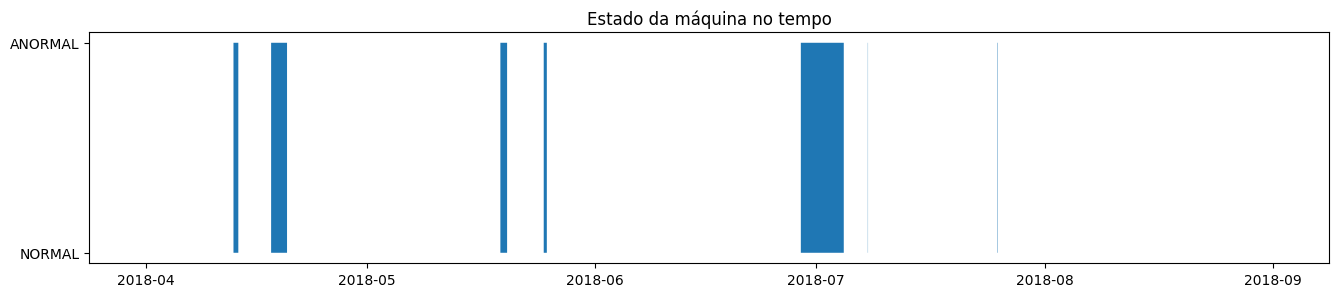

In [16]:
plt.figure(figsize=(16, 3))
plt.fill_between(industry_df.index, 0, industry_df["target"], step="post")

plt.yticks([0, 1], ["NORMAL", "ANORMAL"])
plt.title("Estado da máquina no tempo")
plt.show()

## Visualizando os sensores

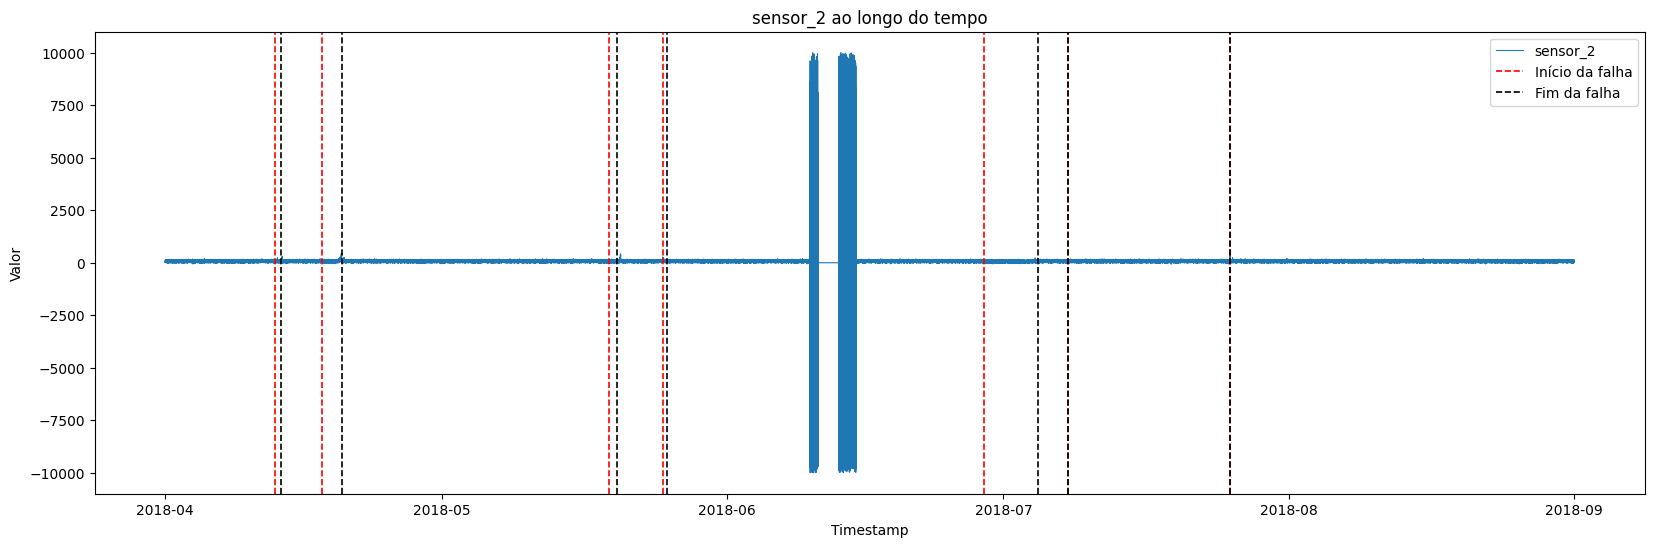

In [37]:
sensor = "sensor_2"
target = industry_df["target"]

inicios = industry_df.index[target.eq(1) & target.shift(fill_value=0).eq(0)]
finais = industry_df.index[target.eq(1) & target.shift(-1, fill_value=0).eq(0)]

fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(
    industry_df.index,
    industry_df[sensor],
    linewidth=0.8,
    label=sensor
)

for i, inicio in enumerate(inicios):
    ax.axvline(
        inicio,
        linestyle="--",
        linewidth=1.2,
        color="red",
        label="Início da falha" if i == 0 else None
    )

for i, final in enumerate(finais):
    ax.axvline(
        final,
        linestyle="--",
        linewidth=1.2,
        color="black",
        label="Fim da falha" if i == 0 else None
    )

ax.set_title(f"{sensor} ao longo do tempo")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Valor")
ax.legend()

plt.show()

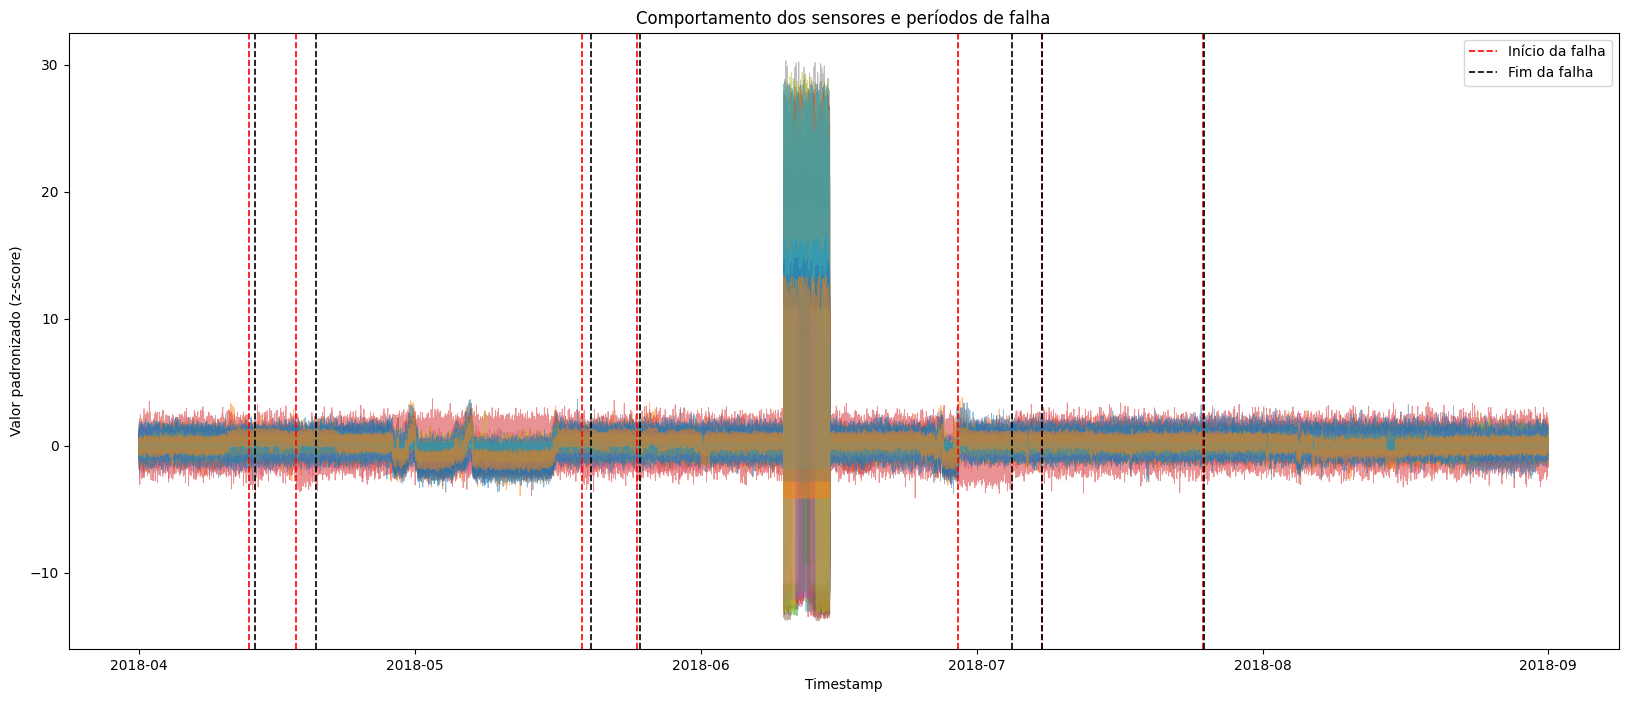

In [33]:
sensor_cols = [f"sensor_{i}" for i in range(52)]

sensors_z = (
    industry_df[sensor_cols] - industry_df[sensor_cols].mean()
) / industry_df[sensor_cols].std()

target = industry_df["target"]

inicios = industry_df.index[target.eq(1) & target.shift(fill_value=0).eq(0)]
finais = industry_df.index[target.eq(1) & target.shift(-1, fill_value=0).eq(0)]

fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(
    sensors_z.index,
    sensors_z,
    linewidth=0.6,
    alpha=0.5
)

for i, inicio in enumerate(inicios):
    ax.axvline(
        inicio,
        linestyle="--",
        linewidth=1.2,
        color="red",
        label="Início da falha" if i == 0 else None
    )

for i, final in enumerate(finais):
    ax.axvline(
        final,
        linestyle="--",
        linewidth=1.2,
        color="black",
        label="Fim da falha" if i == 0 else None
    )

ax.set_title("Comportamento dos sensores e períodos de falha")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Valor padronizado (z-score)")
ax.legend()

plt.show()